# GMPD — Global Mammal Parasite Database

This notebook demonstrates the **GMPD** accessor for the
[Global Mammal Parasite Database](https://parasites.nunn-lab.org/) version 2.0 —
a comprehensive compilation of parasites and pathogens from wild primate,
carnivore, and ungulate hosts, drawn from over 2,700 published scientific
literature sources.

**Citation:** Stephens *et al.* (2017) *Ecology* 98:1476.
https://doi.org/10.1002/ecy.1799

The full main dataset (~24,000 host-parasite records) is downloaded once and
cached on disk, after which all queries are served locally.


In [1]:
from epidatasets.sources.gmpd import GMPDAccessor

gmpd = GMPDAccessor()
print(gmpd)
print(f"Cache directory: {gmpd.cache_dir}")

Global Mammal Parasite Database (GMPD) version 2.0 — a compilation of parasites and pathogens from wild primate, carnivore, and ungulate hosts, with host-parasite association records, standardized taxonomies, sampling metadata, and geospatial information from 2,700+ literature sources. (https://parasites.nunn-lab.org/)
Cache directory: /home/fccoelho/.cache/epi_data/gmpd


## 1. Dataset overview

GMPD covers three host groups and several parasite types (virus, bacteria,
protozoa, helminth, arthropod, fungus).

In [2]:
gmpd.list_host_groups()

,group,description,orders
0,Primates,"Monkeys, apes, and other primates",Primates
1,Carnivores,"Cats, dogs, bears, and other carnivores",Carnivora
2,Ungulates,"Hooved mammals (Artiodactyla, Perissodactyla)","Artiodactyla, Perissodactyla"


In [3]:
gmpd.list_datasets()

,dataset,description,url,available,method
0,GMPD_main,"Main host-parasite association records (24,000...",https://raw.githubusercontent.com/globalbiotic...,True,get_records
1,GMPD_parasite_taxonomy,Parasite taxonomy and transmission modes,,False,
2,GMPD_host_taxonomy,Host taxonomy information,,False,
3,GMPD_references,Bibliographic references for all records,,False,


## 2. Load the main dataset

The first call downloads ``GMPD_main.csv`` (~3 MB) and caches it. Subsequent
calls read from the cache. We start by computing high-level summary
statistics.

In [4]:
summary = gmpd.get_summary_statistics()
summary.T

INFO:epidatasets.sources.gmpd:Fetching GMPD main data (attempt 1/3)


,0
total_records,24323
unique_hosts,462
unique_parasites,2412
unique_citations,2772
unique_localities,3678
host_groups,3
georeferenced_records,19166


## 3. Parasite type composition

How many records and unique parasites does each type contain?

In [5]:
types = gmpd.list_parasite_types()
types

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv


,parasite_type,record_count,unique_parasites,unique_hosts
0,Helminth,10699,1130,329
1,Virus,4009,189,231
2,Protozoa,3151,288,285
3,Bacteria,3135,304,170
4,Arthropod,3129,464,247
5,Fungus,181,41,36
6,Prion,19,2,5


INFO:matplotlib.font_manager:Failed to extract font properties from /usr/share/fonts/truetype/noto/NotoColorEmoji.ttf: Can not load face (unknown file format; error code 0x2)
INFO:matplotlib.font_manager:generated new fontManager


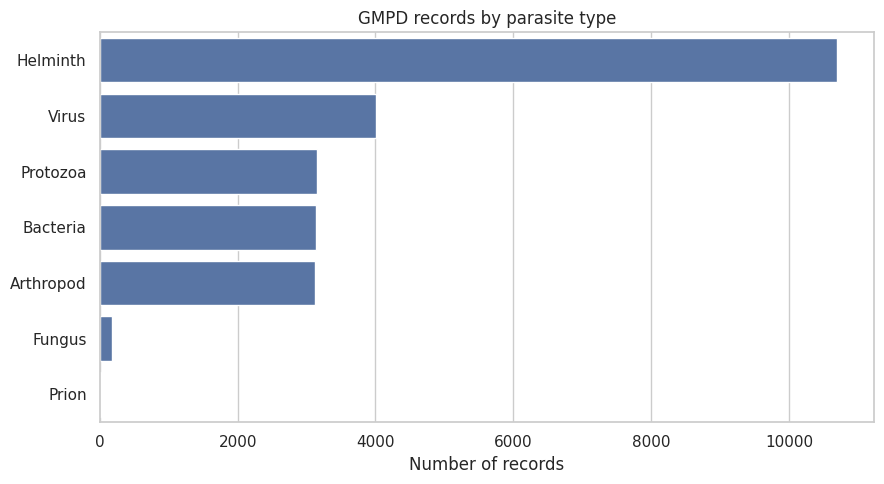

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=types, x="record_count", y="parasite_type", color="#4C72B0", ax=ax)
ax.set(title="GMPD records by parasite type", xlabel="Number of records", ylabel="")
plt.tight_layout()
plt.show()

## 4. Filter by host group and parasite type

Retrieve all **virus** records from **primates**.

In [7]:
primate_viruses = gmpd.get_records(group="Primates", parasite_type="Virus")
print(f"{len(primate_viruses)} primate virus records")
primate_viruses[
    ["host_corrected_name", "host_family", "parasite_corrected_name",
     "location_name", "prevalence", "hosts_sampled"]
].head(10)

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv
INFO:epidatasets.sources.gmpd:Retrieved 815 GMPD records


815 primate virus records


,host_corrected_name,host_family,parasite_corrected_name,location_name,prevalence,hosts_sampled
0,Allenopithecus nigroviridis,Cercopithecidae,Orthopoxvirus Monkeypox virus,Africa,NaN,NaN
1,Alouatta belzebul,Atelidae,Alphavirus Mayaro virus,"Belterra, Brazil",1.000,1.0
2,Alouatta belzebul,Atelidae,Alphavirus Mayaro virus,South America,NaN,NaN
3,Alouatta belzebul,Atelidae,Flavivirus Yellow fever virus,"Belterra, Brazil",1.000,1.0
4,Alouatta caraya,Atelidae,Flavivirus Yellow fever virus,El Pinalito,NaN,NaN
5,Alouatta caraya,Atelidae,Flavivirus Yellow fever virus,El Soberbio,NaN,NaN
6,Alouatta caraya,Atelidae,Flavivirus Yellow fever virus,Garupa,NaN,NaN
7,Alouatta caraya,Atelidae,Flavivirus Yellow fever virus,Guira-Oga,NaN,NaN
8,Alouatta caraya,Atelidae,Flavivirus Yellow fever virus,"Rio Grande Do Sul, Brazil",NaN,NaN
9,Alouatta caraya,Atelidae,Orthopoxvirus sp.,NaN,0.481,27.0


## 5. Unique hosts and parasites

The most frequently sampled host species among carnivores.

In [8]:
carnivore_hosts = gmpd.list_hosts(group="Carnivores")
print(f"{len(carnivore_hosts)} unique carnivore hosts")
carnivore_hosts.head(10)

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv
INFO:epidatasets.sources.gmpd:Retrieved 10528 GMPD records


160 unique carnivore hosts


,host,host_order,host_family,group,record_count
0,Vulpes vulpes,Carnivora,Canidae,Carnivores,1920
1,Procyon lotor,Carnivora,Procyonidae,Carnivores,1266
2,Canis lupus,Carnivora,Canidae,Carnivores,630
3,Canis latrans,Carnivora,Canidae,Carnivores,597
4,Phoca vitulina,Carnivora,Phocidae,Carnivores,366
5,Puma concolor,Carnivora,Felidae,Carnivores,309
6,Meles meles,Carnivora,Mustelidae,Carnivores,285
7,Zalophus californianus,Carnivora,Otariidae,Carnivores,260
8,Ursus americanus,Carnivora,Ursidae,Carnivores,222
9,Panthera leo,Carnivora,Felidae,Carnivores,215


## 6. Host–parasite interactions

Each row is a unique host–parasite pair with the number of supporting records
and literature citations.

In [9]:
interactions = gmpd.get_interactions(parasite_type="Helminth")
print(f"{len(interactions)} unique host–helminth interactions")
interactions.head(10)

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv
INFO:epidatasets.sources.gmpd:Retrieved 10699 GMPD records


3804 unique host–helminth interactions


,host_corrected_name,parasite_corrected_name,record_count,citations
0,Vulpes vulpes,Echinococcus multilocularis,407,"Bagrade et al. 2008, Borecka et al. 2008, Bros..."
1,Procyon lotor,Baylisascaris procyonis,108,"Bafundo et al. 1980, Ching et al. 2000, Cole a..."
2,Vulpes vulpes,Toxocara canis,96,"Al-Sabi et al. 2010, Antolova et al. 2004, Bal..."
3,Vulpes vulpes,Unicinaria stenocephala,72,"Al-Sabi et al. 2010, Clancey et al. 2010, Cria..."
4,Canis latrans,Dirofilaria immitis,66,"Beldomenico et al. 2005b, Conti 1984, Foster e..."
5,Vulpes vulpes,Crenosoma vulpis,53,"Al-Sabi et al. 2010, Bolt et al. 1992, Clancey..."
6,Vulpes vulpes,Trichinella sp.,45,"Airas et al. 2010, Davidson et al. 2006a, Davi..."
7,Odocoileus virginianus,Parelaphostrongylus tenuis,44,"Banks and Ashley 2000, Bogaczyk et al 1993, Ca..."
8,Procyon lotor,Placoconus lotoris,44,"Bafundo et al. 1980, Ching et al. 2000, Cole a..."
9,Vulpes vulpes,Angiostrongylus vasorum,43,"Al-Sabi et al. 2010, Bolt et al. 1992, Gortaza..."


## 7. Georeferenced records

A subset of records carry latitude/longitude coordinates, enabling spatial
analyses of wildlife parasite sampling.

In [10]:
geo = gmpd.get_records(has_coordinates=True)
print(f"{len(geo)} georeferenced records")
geo[["host_corrected_name", "parasite_corrected_name",
     "location_name", "longitude", "latitude"]].head(10)

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv
INFO:epidatasets.sources.gmpd:Retrieved 19166 GMPD records


19166 georeferenced records


,host_corrected_name,parasite_corrected_name,location_name,longitude,latitude
0,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia and South Africa,18.49,-22.96
1,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia and South Africa,18.49,-22.96
2,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
3,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
4,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
5,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
6,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
7,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
8,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96
9,Acinonyx jubatus,Alphacoronavirus Alphacoronavirus 1,Namibia,18.49,-22.96


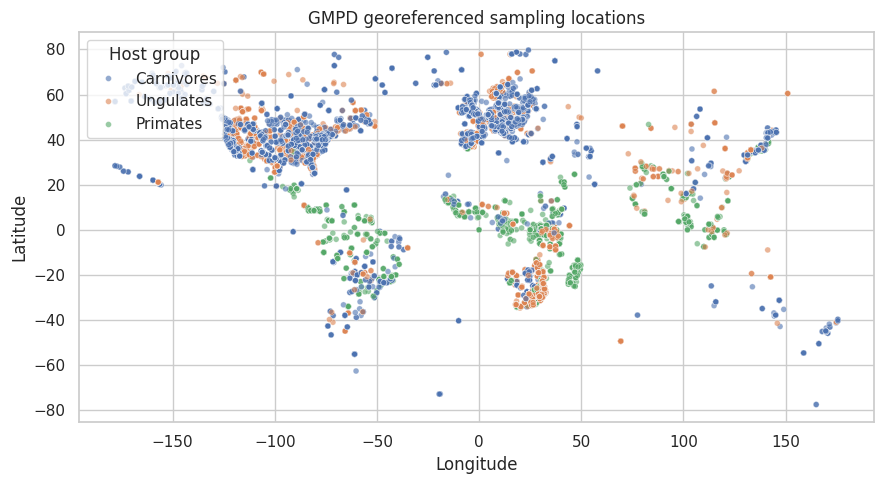

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(
    data=geo, x="longitude", y="latitude", hue="group", s=18,
    alpha=0.6, ax=ax,
)
ax.set(
    title="GMPD georeferenced sampling locations",
    xlabel="Longitude", ylabel="Latitude",
)
ax.legend(title="Host group", loc="upper left")
plt.tight_layout()
plt.show()

## 8. Keyword search

Search host and parasite names for a case-insensitive substring.

In [12]:
plasmodium = gmpd.search_records("Plasmodium")
print(f"{len(plasmodium)} records mention 'Plasmodium'")
plasmodium["parasite_corrected_name"].value_counts().head(10)

INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv


353 records mention 'Plasmodium'


parasite_corrected_name
Plasmodium brasilianum    95
Plasmodium falciparum     56
Plasmodium sp.            41
Plasmodium inui           24
Plasmodium cynomolgi      22
Plasmodium gonderi        14
Plasmodium simium         12
Plasmodium vivax          12
Plasmodium knowlesi       10
Plasmodium coatneyi        8
Name: count, dtype: int64

## 9. Using the plugin registry

The accessor is reachable through the unified ``get_source`` API.

In [13]:
from epidatasets import get_source, list_sources

print("gmpd" in list_sources())
gmpd2 = get_source("gmpd")
gmpd2.get_summary_statistics().T

INFO:epidatasets.sources.eurostat:eurostat library not installed. Using REST API fallback.
INFO:epidatasets.sources.gmpd:Loading cached GMPD data: /home/fccoelho/.cache/epi_data/gmpd/GMPD_main.csv


True


,0
total_records,24323
unique_hosts,462
unique_parasites,2412
unique_citations,2772
unique_localities,3678
host_groups,3
georeferenced_records,19166


## Key takeaways

- GMPD provides 24,000+ host–parasite records for wild mammals worldwide.
- Filter by host group, parasite type, host/parasite name, or coordinates.
- ``get_interactions`` returns deduplicated host–parasite pairs with citations.
- Data is cached locally after the first download for fast repeat queries.

**Reference:**
Stephens, P.R., Pappalardo, P., Huang, S., *et al.* (2017). Global Mammal
Parasite Database version 2.0. *Ecology*, 98(5), 1476.
https://doi.org/10.1002/ecy.1799